In [1]:
import os
import geopandas as gpd

# Change to project root before importing local src modules
os.chdir('../..')
from src.geoadmin import load_laraic, get_landbase_bymask, load_assessor_parcels_bygeom


In [ ]:

# ── Paths ──────────────────────────────────────────────────────────────────
NEARMAP_DIR  = '/Users/adamswietek/Downloads/USC_Nearmap_Sample_Data'
NEARMAP_TILE = f'{NEARMAP_DIR}/IMAGERY_SAMPLE_EPSG3857_Date20251005/Tiles.shp'

nearmap_tile     = gpd.read_file(NEARMAP_TILE)

# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR  = '/Users/adamswietek/Documents/PostDoc/HiddenHousing/'
ASSESSOR_NM = f'{BASE_DIR}/data/processed/nm_parcel_joined.gpkg'

assessor_nm     = gpd.read_file(ASSESSOR_NM)
CRS = assessor_nm.crs
nearmap_tile.to_crs(CRS, inplace = True)
print(CRS)
# ── Paths ──────────────────────────────────────────────────────────────────

fp = '/Users/adamswietek/Documents/PostDoc/data/raw_la/LACounty_Parcels.gdb'

CRS = gpd.read_file(fp, rows=1).crs
assessor_parcel = gpd.read_file(fp, mask = nearmap_tile.to_crs(CRS))
assessor_parcel.to_crs(CRS, inplace = True)



EPSG:2229


ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/core.py:280: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return ogr_read_info(
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/geopandas/io/file.py:521: UserWarning: More than one layer found in 'LARIAC6_Buildings_2020.gdb': 'LARIAC6_BUILDINGS_2020' (default), 'LARIAC5_BUILDINGS_DELETED_2020'. Specify layer parameter to avoid this warning.
  crs = pyogrio.read_info(pa

In [15]:
assessor_lar = gpd.sjoin(lariac, assessor_parcel, how = 'left')


In [ ]:
assessor_parcel['UseDescription']

0       Utility Commercial & Mutual: Pumping Plants St...
1                                                  Single
2                Parking Lots (Commercial Use Properties)
3                                              Industrial
4                                              Industrial
                              ...                        
3473                                               Single
3474                                    Store Combination
3475    Lgt Manf.Sm. EQPT. Manuf Sm.Shps Instr.Manuf. ...
3476                                           Commercial
3477                                           Industrial
Name: UseDescription, Length: 3478, dtype: object

In [46]:
import pandas as pd
results = {
    'usetype': assessor_parcel.groupby('AIN')['UseDescription'].first(),
    'SQFTmain1':assessor_parcel.groupby('AIN')['SQFTmain1'].first(),
    'nm_area': assessor_nm.groupby('AIN')['areaSqft'].sum(),
    'lar_area':assessor_lar.groupby('AIN')['AREA'].sum()
}

df = pd.DataFrame(results)


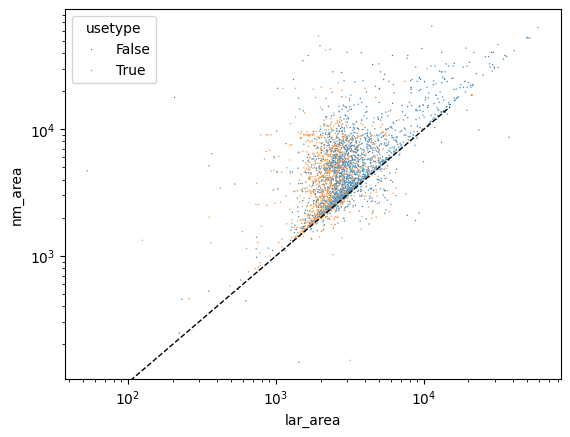

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(data = df, x= 'lar_area', y = 'nm_area', s= 1, hue = df['usetype'] == 'Single')

plt.xscale('log'), plt.yscale('log')
plt.plot([0, 15000], [0, 15000], 'k--', lw=1, label='1:1')

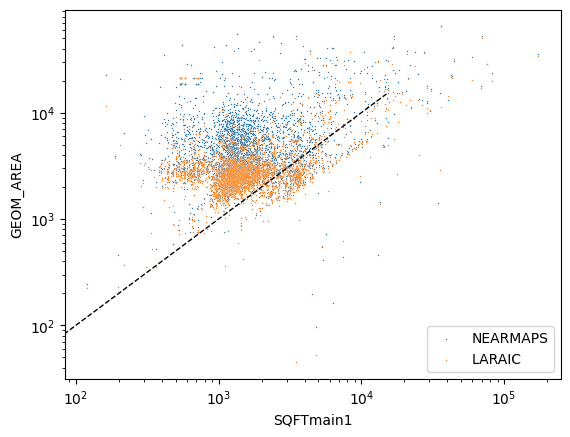

In [37]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


sns.scatterplot(data = df, x= 'SQFTmain1', y = 'nm_area', label = 'NEARMAPS', s = 1)
sns.scatterplot(data = df, x= 'SQFTmain1', y = 'lar_area', label = 'LARAIC', s= 1)

plt.xscale('log'), plt.yscale('log'), plt.ylabel('GEOM_AREA')
plt.plot([0, 15000], [0, 15000], 'k--', lw=1, label='1:1')